In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Same style for all graphics 
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# settings for columns in pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("../vehicles_us.csv", encoding="utf-8")


df.info()
df.describe(include="all").T
df.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  str    
 3   condition     51525 non-null  str    
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  str    
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  str    
 8   type          51525 non-null  str    
 9   paint_color   42258 non-null  str    
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  str    
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 7.7 MB


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28
5,14990,2014.0,chrysler 300,excellent,6.0,gas,57954.0,automatic,sedan,black,1.0,2018-06-20,15
6,12990,2015.0,toyota camry,excellent,4.0,gas,79212.0,automatic,sedan,white,NaN,2018-12-27,73
7,15990,2013.0,honda pilot,excellent,6.0,gas,109473.0,automatic,SUV,black,1.0,2019-01-07,68
8,11500,2012.0,kia sorento,excellent,4.0,gas,104174.0,automatic,SUV,NaN,1.0,2018-07-16,19
9,9200,2008.0,honda pilot,excellent,NaN,gas,147191.0,automatic,SUV,blue,1.0,2019-02-15,17


In [10]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    #resume of null values per column
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(2)
    return (
        pd.DataFrame({"nulls": miss, "pct": pct})
        .query("nulls > 0")
        .sort_values("pct", ascending=False)
    )

missing_summary(df)

print("Exact quantity of duplicated values:", df.duplicated().sum())

for col in df.columns:
    print(f"{col:20s} → {df[col].nunique():>6} uniques")

# is_4wd needs to be boolean
print(df["is_4wd"].value_counts(dropna=False))

# date_posted must be datetime
print(df["date_posted"].dtype)

Exact quantity of duplicated values: 0
price                →   3443 uniques
model_year           →     68 uniques
model                →    100 uniques
condition            →      6 uniques
cylinders            →      7 uniques
fuel                 →      5 uniques
odometer             →  17762 uniques
transmission         →      3 uniques
type                 →     13 uniques
paint_color          →     12 uniques
is_4wd               →      1 uniques
date_posted          →    354 uniques
days_listed          →    227 uniques
is_4wd
NaN    25953
1.0    25572
Name: count, dtype: int64
str


### Cleaning data

In [14]:
df_clean = df.copy()

df_clean["date_posted"] = pd.to_datetime(df_clean["date_posted"], errors="coerce")
df_clean["is_4wd"] = df_clean["is_4wd"].fillna(0).astype(bool)
df_clean["cylinders"] = df_clean["cylinders"].astype("Int64")
df_clean["model_year"] = df_clean["model_year"].astype("Int64")

def iqr_outlier_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ["price", "odometer"]:
    low, high = iqr_outlier_bounds(df_clean[col])
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f"{col:10s}: limits = ({low:.0f}, {high:.0f})  outliers = {n_out}")

price     : limits = (-12758, 34598)  outliers = 1646
odometer  : limits = (-57500, 282500)  outliers = 487


In [16]:
low_p, high_p = iqr_outlier_bounds(df_clean["price"])
low_o, high_o = iqr_outlier_bounds(df_clean["odometer"])

df_clean["is_price_outlier"]    = (df_clean["price"]    < low_p) | (df_clean["price"]    > high_p)
df_clean["is_odometer_outlier"] = (df_clean["odometer"] < low_o) | (df_clean["odometer"] > high_o)

df_clean.loc[df_clean["is_price_outlier"], "price"].describe()

df_analysis = df_clean.query("0 < price < 100_000 and 0 < odometer < 500_000").copy()
print(f"Rows before: {len(df_clean)}, rows after: {len(df_analysis)} "
      f"({(1 - len(df_analysis)/len(df_clean))*100:.1f}% deleted)")

Rows before: 51525, rows after: 43410 (15.7% deleted)


# Univariate Analysis

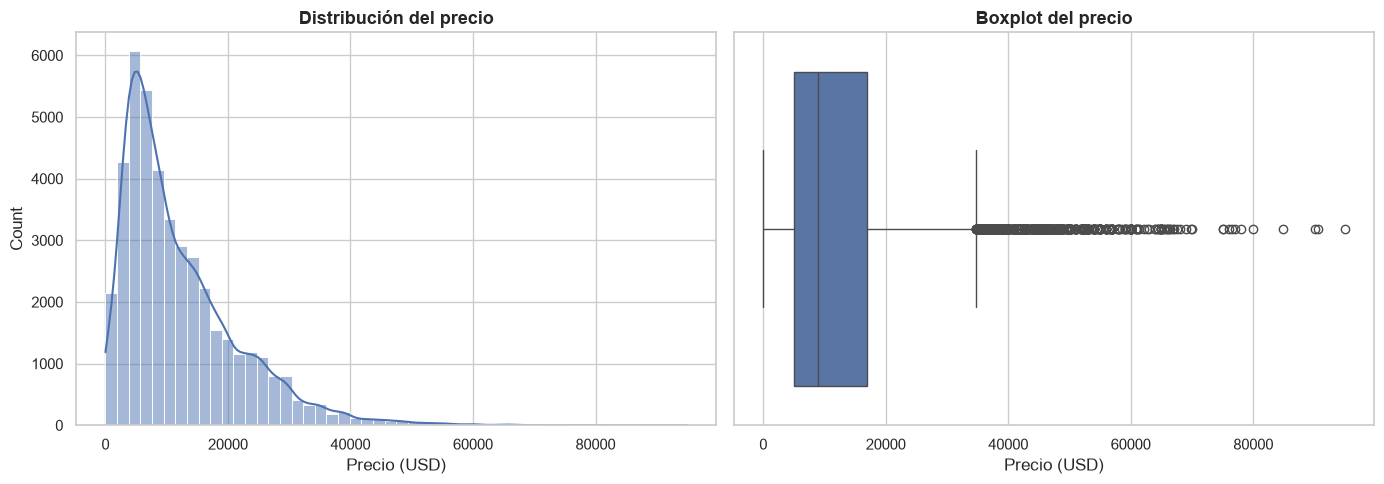

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_analysis["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución del precio")
axes[0].set_xlabel("Precio (USD)")

sns.boxplot(x=df_analysis["price"], ax=axes[1])
axes[1].set_title("Boxplot del precio")
axes[1].set_xlabel("Precio (USD)")

plt.tight_layout()
plt.show()

In [18]:
print(df_analysis["price"].describe())
print(f"Median: {df_analysis['price'].median():.0f}")
print(f"Mean:   {df_analysis['price'].mean():.0f}")

count    43410.000000
mean     12099.401405
std       9547.483097
min          1.000000
25%       5000.000000
50%       9000.000000
75%      16888.000000
max      94955.000000
Name: price, dtype: float64
Median: 9000
Mean:   12099


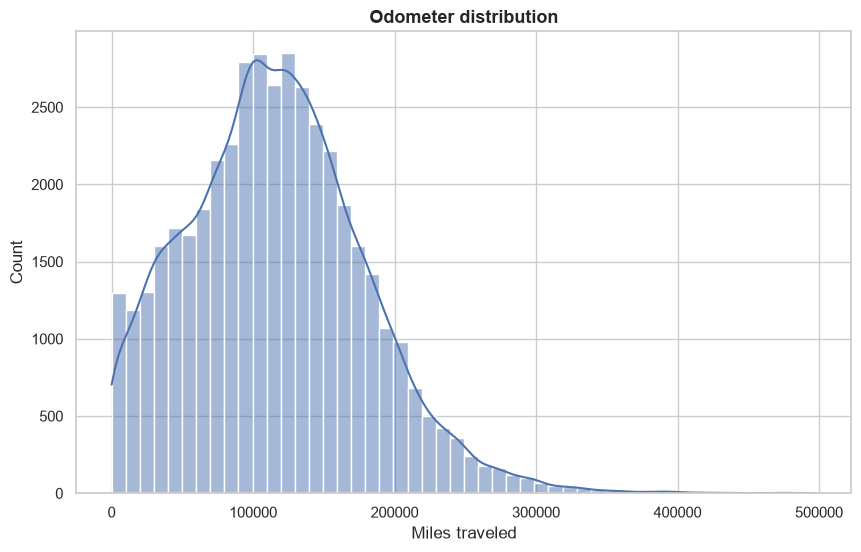

In [19]:
sns.histplot(df_analysis["odometer"], bins=50, kde=True)
plt.title("Odometer distribution")
plt.xlabel("Miles traveled")
plt.show()

### Categorical variables

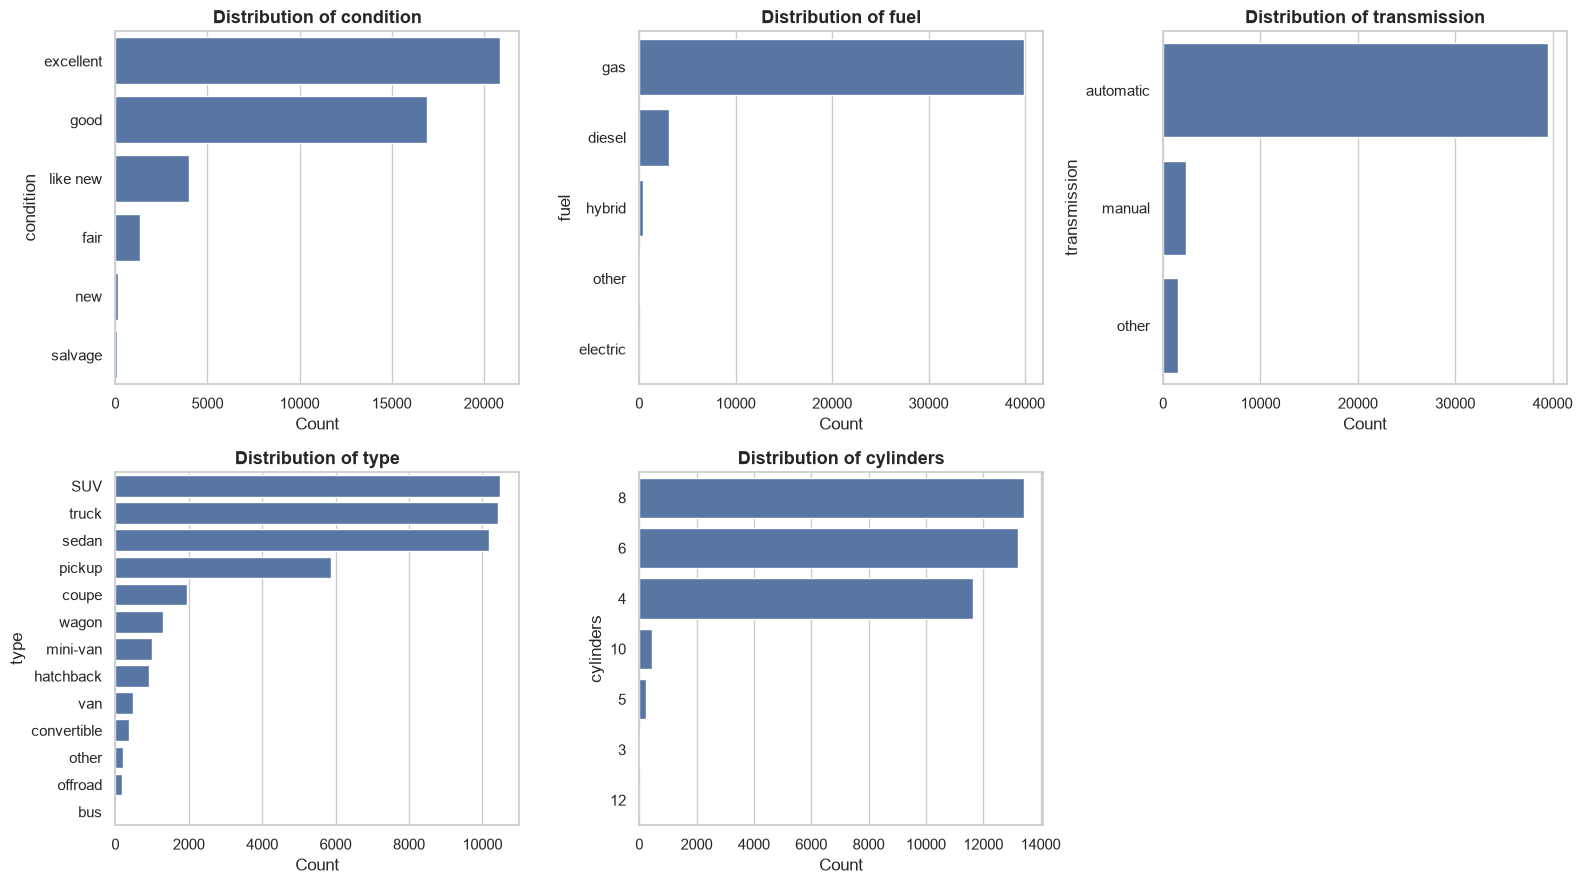

In [20]:
cat_cols = ["condition", "fuel", "transmission", "type", "cylinders"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = df_analysis[col].value_counts().index
    sns.countplot(data=df_analysis, y=col, order=order, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Count")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

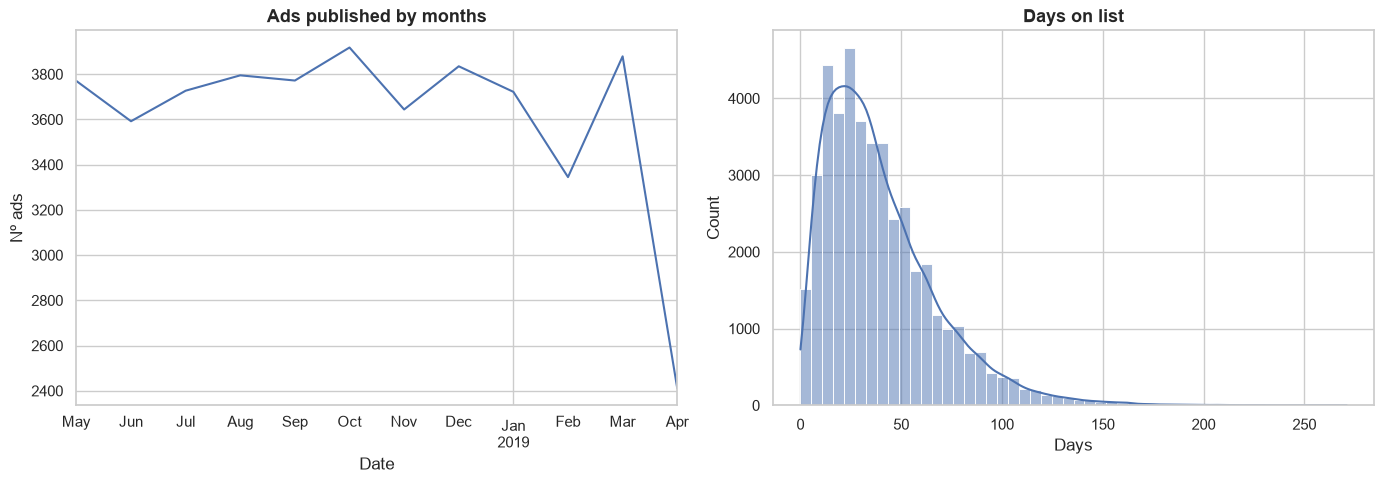

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_analysis.set_index("date_posted").resample("ME").size().plot(ax=axes[0])
axes[0].set_title("Ads published by months")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Nº ads")

sns.histplot(df_analysis["days_listed"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Days on list")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

# Bivariate Analysis

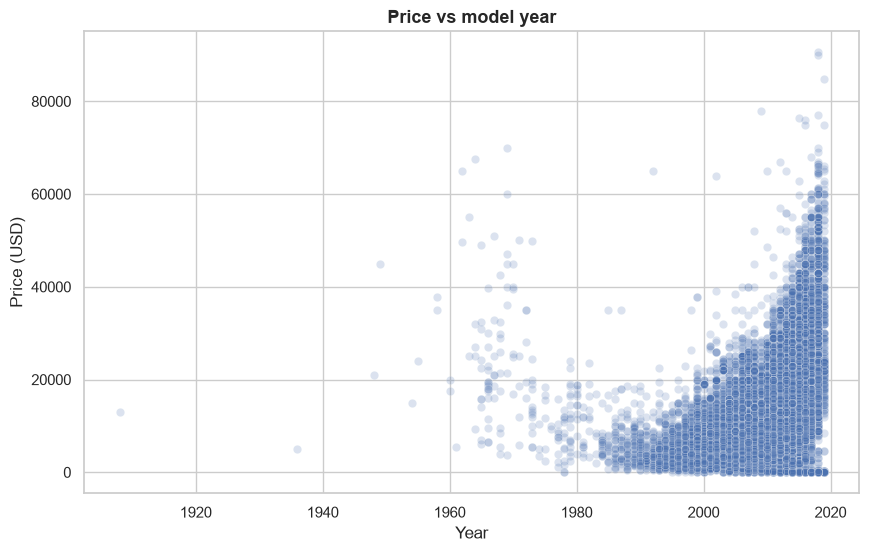

In [27]:
sns.scatterplot(data=df_analysis, x="model_year", y="price", alpha=0.2)
plt.title("Price vs model year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

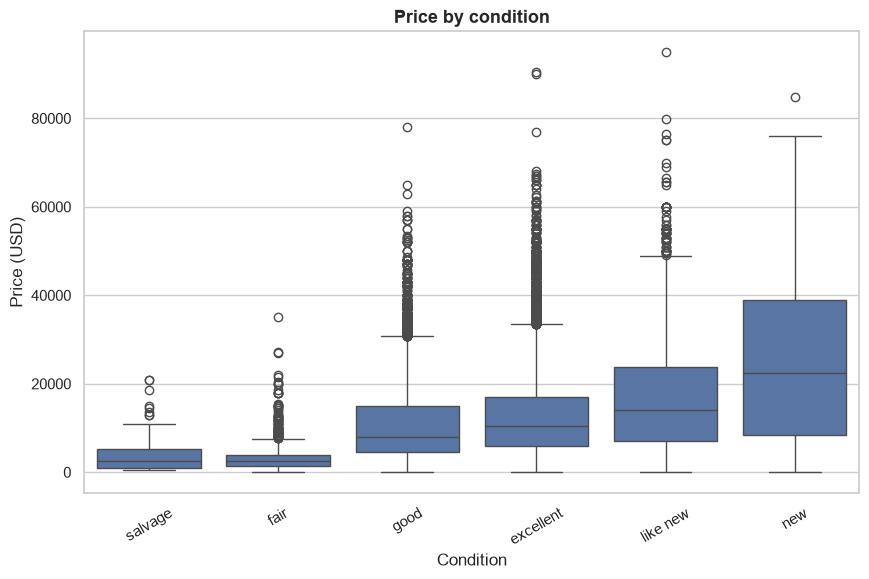

In [29]:
order = ["salvage", "fair", "good", "excellent", "like new", "new"]
sns.boxplot(data=df_analysis, x="condition", y="price", order=order)
plt.title("Price by condition")
plt.xlabel("Condition")
plt.ylabel("Price (USD)")
plt.xticks(rotation=30)
plt.show()

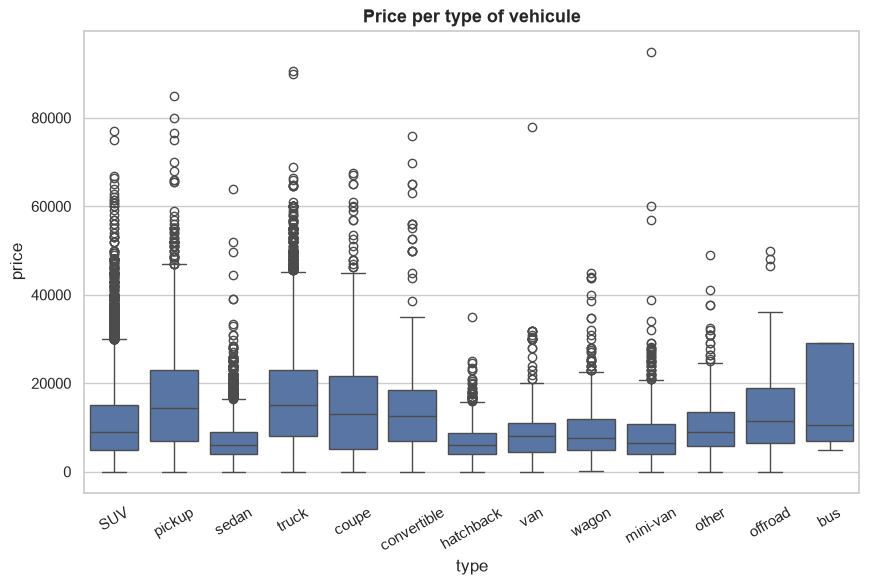

In [30]:
sns.boxplot(data=df_analysis, x="type", y="price")
plt.title("Price per type of vehicule")
plt.xticks(rotation=30)
plt.show()

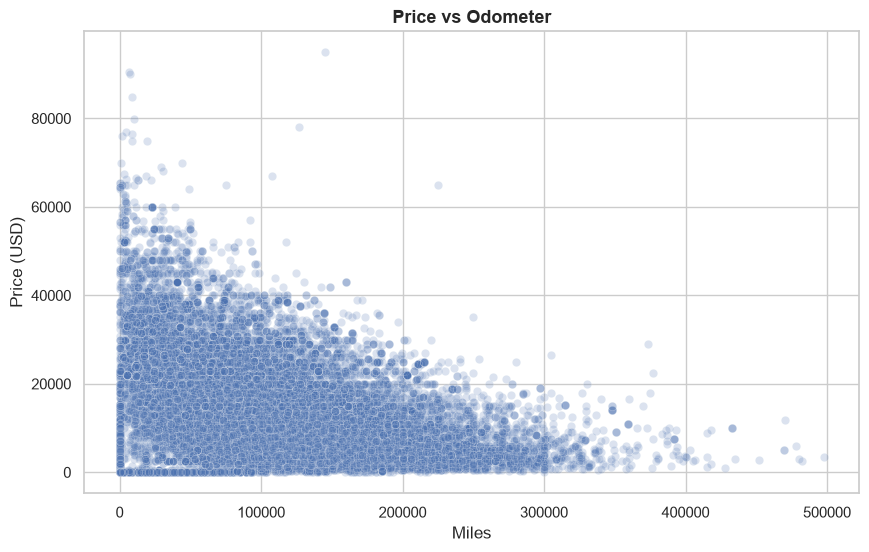

In [31]:
sns.scatterplot(data=df_analysis, x="odometer", y="price", alpha=0.2)
plt.title("Price vs Odometer")
plt.xlabel("Miles")
plt.ylabel("Price (USD)")
plt.show()


# Multivariate Analisys

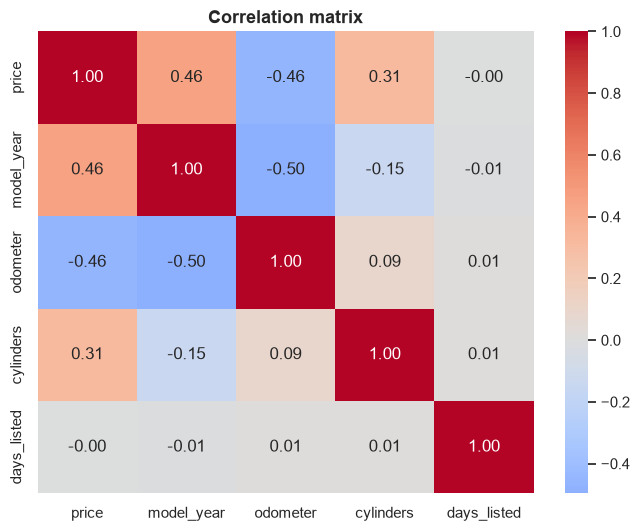

In [32]:
num_cols = ["price", "model_year", "odometer", "cylinders", "days_listed"]
corr = df_analysis[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

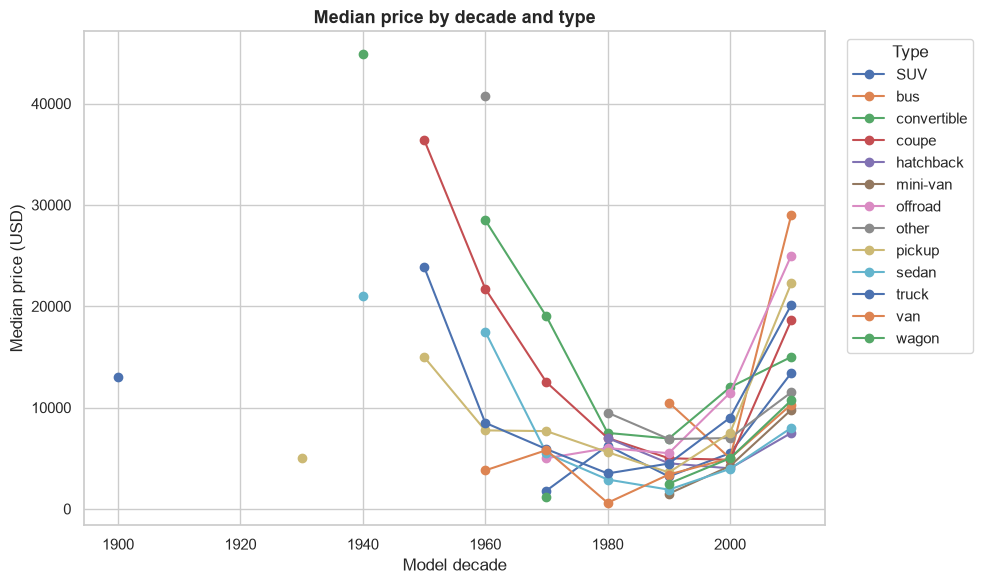

In [34]:
pivot = (
    df_analysis
    .assign(decade=lambda d: (d["model_year"] // 10) * 10)
    .groupby(["decade", "type"])["price"]
    .median()
    .unstack()
)

pivot.plot(marker="o")
plt.title("Median price by decade and type")
plt.xlabel("Model decade")
plt.ylabel("Median price (USD)")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [35]:
summary = f"""EDA SUMMARY
-----------
Analyzed rows:         {len(df_analysis):,}
Median price:          ${df_analysis['price'].median():,.0f}
Mean price:            ${df_analysis['price'].mean():,.0f}
Median odometer:       {df_analysis['odometer'].median():,.0f} miles
Days listed (median):  {df_analysis['days_listed'].median():.0f} days
TOP 3 types by volume:
{df_analysis['type'].value_counts().head(3).to_string()}
TOP 3 makes/models by volume:
{df_analysis['model'].str.split().str[0].value_counts().head(3).to_string()}
"""
print(summary)

EDA SUMMARY
-----------
Analyzed rows:         43,410
Median price:          $9,000
Mean price:            $12,099
Median odometer:       113,172 miles
Days listed (median):  33 days
TOP 3 types by volume:
type
SUV      10482
truck    10430
sedan    10184
TOP 3 makes/models by volume:
model
ford         10685
chevrolet     8966
toyota        4613



Findings:

Right-skewed price. Report the median, not the mean. The mean is inflated by a minority of expensive vehicles.

Year and odometer are the strongest predictors of price (~0.5 absolute correlations).

Condition alone does not discriminate well. There is significant overlap between categories; it must be combined with other variables.

is_4wd comes as a float with ~50% nulls. It is interpreted as "not 4WD" (missing flag). If your hypothesis were "we don't know", the treatment should be different.

There are clearly erroneous price outliers ($1, $999,999) that should be addressed before modeling.

The dataset covers ~1 year of listings (late 2018 – mid-2019). Be careful when generalizing to other seasons.